# Sales Forecasting — LightGBM + Recursive Forecasting

**Mục tiêu:** Dự báo `Revenue` và `COGS` hàng ngày cho giai đoạn **01/01/2023 – 01/07/2024** (548 ngày).

**Phương pháp:**
- Mô hình: **LightGBM** (Gradient Boosting trên cây quyết định)
- Target: Train trên **log-space** (`log1p`) để ổn định phương sai
- Inference: **Recursive Forecasting** — dự báo từng ngày, dùng kết quả ngày trước làm input cho ngày sau

---

## Pipeline tổng quan

```
Raw Data (sales.csv + web_traffic.csv)
        ↓
Feature Engineering (calendar + lag + Fourier)
        ↓
Train LightGBM (train < 2022, val = 2022)
        ↓
Recursive Forecast (2023–2024, cập nhật lag mỗi ngày)
        ↓
submission.csv
```

---

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

---

## 2. Load dữ liệu

Load toàn bộ file CSV trong thư mục Data vào các biến `df_<tên_file>`.

Các file quan trọng nhất cho bài toán này:
- `df_sales` — doanh thu hàng ngày (train: 2012–2022)
- `df_web_traffic` — lưu lượng truy cập website hàng ngày

In [2]:
import os

path = r'C:\Users\ACER\Documents\datathon-2026-round-1\Datathon_Contest_UITUT\Data'  # <- Thay đổi đường dẫn

files = [f for f in os.listdir(path) if f.endswith('.csv')]

for file in files:
    file_name = os.path.splitext(file)[0]
    full_path = os.path.join(path, file)
    globals()[f"df_{file_name}"] = pd.read_csv(full_path)
    print(f"Đã load xong: df_{file_name}")

Đã load xong: df_customers
Đã load xong: df_geography
Đã load xong: df_inventory
Đã load xong: df_orders
Đã load xong: df_order_items
Đã load xong: df_payments
Đã load xong: df_products
Đã load xong: df_promotions
Đã load xong: df_returns
Đã load xong: df_reviews
Đã load xong: df_sales
Đã load xong: df_sample_submission
Đã load xong: df_shipments
Đã load xong: df_web_traffic


---

## 3. Feature Engineering

Đây là bước quan trọng nhất. Vì horizon dự báo dài (18 tháng), ta **không thể dùng lag trực tiếp từ tương lai** — lag phải được cập nhật đệ quy trong lúc predict.

### Tổng quan các nhóm feature:

| Nhóm | Feature | Lý do |
|---|---|---|
| **Calendar** | `month`, `day`, `dow` | Capture seasonality theo tháng, ngày |
| **Binary flag** | `is_weekend`, `is_payday`, `is_double_date` | Các ngày đặc biệt có pattern riêng |
| **External** | `sessions` | Web traffic là leading indicator của doanh thu |
| **Fourier** | `sin_year`, `cos_year` | Encode chu kỳ năm dạng continuous, smooth hơn one-hot |
| **Lag** | `rev_lag_1/7/30`, `cogs_lag_1/7/30` | Momentum của doanh thu gần đây |

---

### Chi tiết từng feature:

#### 📅 Calendar Features
- **`month`** (1–12): Capture seasonality theo tháng — tháng 11/12 thường cao (cuối năm), tháng 1/2 thấp (sau Tết).
- **`day`** (1–31): Ngày cuối tháng thường có spike (lương tháng, deadline thanh toán).
- **`dow`** (0=Thứ Hai, 6=Chủ Nhật): Pattern khác nhau giữa ngày thường và cuối tuần.

#### 🚩 Binary Flag Features
- **`is_weekend`**: 1 nếu Thứ Bảy hoặc Chủ Nhật. Với e-commerce B2C, weekend thường có traffic cao hơn.
- **`is_payday`**: 1 nếu ngày 15, 30, hoặc 31 — ngày nhận lương phổ biến, khách có xu hướng mua sắm nhiều hơn.
- **`is_double_date`**: 1 nếu ngày = tháng (1/1, 2/2, ..., 12/12) — các ngày flash sale nổi tiếng ở Việt Nam (11/11, 12/12).

#### 📡 External Feature
- **`sessions`**: Tổng số phiên truy cập website mỗi ngày từ `web_traffic.csv`. Web traffic là **leading indicator** — tăng traffic thường dẫn đến tăng đơn hàng sau 0–2 ngày.
  - Dùng `ffill()` để fill NaN trong giai đoạn test (không có data tương lai).

#### 🌊 Fourier Features (Seasonality Encoding)
- **`sin_year`** và **`cos_year`**: Encode ngày trong năm (`dayofyear`) dưới dạng sóng sin/cos.
  - Công thức: `sin(2π × doy / 365.25)` và `cos(2π × doy / 365.25)`
  - **Tại sao không dùng `month` thuần?** — `month` là categorical rời rạc, nhảy đột ngột từ 12 → 1. Fourier tạo ra transition mượt, giúp model học seasonality tốt hơn, đặc biệt quan trọng cho Ridge Regression.
  - Chỉ dùng k=1 (1 cặp sin/cos) → capture chu kỳ năm cơ bản. Có thể thêm k=2,3 để capture harmonics (chu kỳ 6 tháng, 4 tháng).

#### 📈 Lag Features (Momentum)
- **`rev_lag_1`**: Log revenue ngày hôm qua → capture short-term momentum.
- **`rev_lag_7`**: Log revenue 7 ngày trước → capture weekly pattern (cùng thứ trong tuần tuần trước).
- **`rev_lag_30`**: Log revenue 30 ngày trước → capture monthly seasonality (cùng kỳ tháng trước).
- **`cogs_lag_1/7`**: COGS lags tương tự → giúp model học mối quan hệ Revenue–COGS.

> **⚠️ Lưu ý Recursive Forecasting:** Trong giai đoạn test (2023–2024), ta không có giá trị Revenue thực tế. Do đó lag phải được **cập nhật từng ngày** bằng giá trị dự báo của ngày trước — đây là lý do cần vòng lặp recursive ở Bước 3.

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")


def build_expert_data(df_sales, df_web_traffic):
    """
    Xây dựng bảng feature đầy đủ cho toàn bộ timeline (train + test).
    
    Args:
        df_sales        : DataFrame chứa Date, Revenue, COGS (2012–2022)
        df_web_traffic  : DataFrame chứa date, sessions (hàng ngày)
    
    Returns:
        df : DataFrame với đầy đủ features cho mọi ngày từ 2012-07-04 đến 2024-07-01
    """
    
    # ── Chuẩn bị dữ liệu gốc ────────────────────────────────
    sales = df_sales.copy()
    sales['Date'] = pd.to_datetime(sales['Date'])
    
    # Gom web traffic theo ngày (nếu có nhiều dòng/ngày)
    web = (df_web_traffic
           .groupby('date')['sessions'].sum()
           .reset_index()
           .rename(columns={'date': 'Date'}))
    web['Date'] = pd.to_datetime(web['Date'])
    
    # ── Tạo khung thời gian đầy đủ ──────────────────────────
    # Bao gồm cả giai đoạn test (2023–2024) để tính lag liên tục
    all_dates = pd.date_range(start=sales['Date'].min(), end='2024-07-01', freq='D')
    df = pd.DataFrame({'Date': all_dates})
    
    # Merge Revenue/COGS (chỉ có ở train period, NaN ở test)
    df = pd.merge(df, sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')
    # Merge web traffic
    df = pd.merge(df, web, on='Date', how='left')
    
    # Fill sessions: dùng forward fill vì traffic tương lai không biết trước
    df['sessions'] = df['sessions'].ffill().fillna(0)
    
    # ── Target: Log Transformation ───────────────────────────
    # log1p(x) = log(1 + x): ổn định phương sai, xử lý right-skewed distribution
    # Dùng fillna(0) cho test period (NaN → 0 → log1p(0) = 0)
    df['log_rev']  = np.log1p(df['Revenue'].fillna(0))
    df['log_cogs'] = np.log1p(df['COGS'].fillna(0))
    
    # ── Calendar Features ────────────────────────────────────
    df['month'] = df['Date'].dt.month          # 1–12: seasonality theo tháng
    df['day']   = df['Date'].dt.day            # 1–31: pattern trong tháng
    df['dow']   = df['Date'].dt.dayofweek      # 0=Mon, 6=Sun
    
    # ── Binary Flag Features ─────────────────────────────────
    df['is_weekend']     = (df['dow'] >= 5).astype(int)           # Thứ 7, CN
    df['is_payday']      = df['day'].isin([15, 30, 31]).astype(int)  # Ngày lương
    df['is_double_date'] = (df['day'] == df['month']).astype(int) # 11/11, 12/12...
    
    # ── Fourier Features (Annual Seasonality) ────────────────
    doy = df['Date'].dt.dayofyear  # Day of year: 1–365
    # k=1: capture chu kỳ cơ bản 1 năm
    df['sin_year'] = np.sin(2 * np.pi * doy / 365.25)
    df['cos_year'] = np.cos(2 * np.pi * doy / 365.25)
    
    # ── Lag Features (Momentum) ──────────────────────────────
    # Khởi tạo lag từ lịch sử train — sẽ được cập nhật đệ quy ở test
    for lag in [1, 2, 7, 14, 30]:
        df[f'rev_lag_{lag}']  = df['log_rev'].shift(lag).fillna(0)
        df[f'cogs_lag_{lag}'] = df['log_cogs'].shift(lag).fillna(0)
    
    return df


# Build feature table
df_final = build_expert_data(df_sales, df_web_traffic)
print(f"Dataset shape: {df_final.shape}")
print(f"Date range: {df_final['Date'].min().date()} → {df_final['Date'].max().date()}")
df_final.head()

Dataset shape: (4381, 24)
Date range: 2012-07-04 → 2024-07-01


,Date,Revenue,COGS,sessions,log_rev,log_cogs,month,day,dow,is_weekend,...,rev_lag_1,cogs_lag_1,rev_lag_2,cogs_lag_2,rev_lag_7,cogs_lag_7,rev_lag_14,cogs_lag_14,rev_lag_30,cogs_lag_30
0,2012-07-04,5123547.94,3982991.19,0.0,15.449358,15.197544,7,4,2,0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,2012-07-05,2751773.45,2150580.23,0.0,14.827757,14.581249,7,5,3,0,...,15.449358,15.197544,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,2012-07-06,3054029.42,2517632.84,0.0,14.931973,14.738830,7,6,4,0,...,14.827757,14.581249,15.449358,15.197544,0.0,0.0,0.0,0.0,0.0,0.0
3,2012-07-07,2667930.94,2108246.62,0.0,14.796814,14.561368,7,7,5,1,...,14.931973,14.738830,14.827757,14.581249,0.0,0.0,0.0,0.0,0.0,0.0
4,2012-07-08,2360851.90,1808622.79,0.0,14.674534,14.408077,7,8,6,1,...,14.796814,14.561368,14.931973,14.738830,0.0,0.0,0.0,0.0,0.0,0.0


---

## 4. Định nghĩa Features & Chia tập dữ liệu

### Feature list được chọn:
```
Calendar  : month, day, dow
Binary    : is_weekend, is_payday, is_double_date
External  : sessions
Fourier   : sin_year, cos_year
Lag (Rev) : rev_lag_1, rev_lag_7, rev_lag_30
Lag (COGS): cogs_lag_1, cogs_lag_7
```

### Chiến lược chia tập:
- **Train**: 2012–2021 — học pattern lịch sử
- **Validation**: 2022 — đánh giá model trên năm gần nhất (phân phối gần nhất với test)
- **Test**: 2023–2024 — giai đoạn cần dự báo (không có ground truth)

> **Tại sao validation = 2022?** Năm 2022 có phân phối gần nhất với test (2023–2024), giúp đánh giá model trên điều kiện gần thực tế nhất.

In [4]:
# Feature list
FEATURES = [
    # Calendar
    'month', 'day', 'dow',
    # Binary flags
    'is_weekend', 'is_payday', 'is_double_date',
    # External signal
    'sessions',
    # Fourier (annual seasonality)
    'sin_year', 'cos_year',
    # Lag revenue (short/medium/long-term momentum)
    'rev_lag_1', 'rev_lag_7', 'rev_lag_30',
    # Lag COGS (Revenue-COGS relationship)
    'cogs_lag_1', 'cogs_lag_7'
]

# Train/Val/Test split theo thời gian
train_mask = df_final['Date'] < '2022-01-01'
val_mask   = (df_final['Date'] >= '2022-01-01') & (df_final['Date'] <= '2022-12-31')
test_mask  = df_final['Date'] >= '2023-01-01'

train_df = df_final[train_mask]
val_df   = df_final[val_mask]
test_df  = df_final[test_mask]

print(f"Train: {train_df['Date'].min().date()} → {train_df['Date'].max().date()} ({len(train_df)} rows)")
print(f"Val  : {val_df['Date'].min().date()} → {val_df['Date'].max().date()} ({len(val_df)} rows)")
print(f"Test : {test_df['Date'].min().date()} → {test_df['Date'].max().date()} ({len(test_df)} rows)")

Train: 2012-07-04 → 2021-12-31 (3468 rows)
Val  : 2022-01-01 → 2022-12-31 (365 rows)
Test : 2023-01-01 → 2024-07-01 (548 rows)


---

## 5. Huấn luyện mô hình LightGBM

### Tại sao chọn LightGBM?
- **Tốc độ**: Nhanh hơn XGBoost nhờ histogram-based splits
- **Hiệu năng**: Tốt với tabular data có nhiều categorical features
- **Early stopping**: Tự động dừng khi validation không cải thiện → tránh overfit

### Giải thích hyperparameters:
| Parameter | Giá trị | Ý nghĩa |
|---|---|---|
| `objective` | `regression` | Hồi quy (predict giá trị liên tục) |
| `metric` | `rmse` | Đánh giá bằng Root Mean Squared Error |
| `learning_rate` | `0.02` | Nhỏ = học chậm nhưng ổn định hơn |
| `num_leaves` | `31` | Độ phức tạp cây — 31 là mức conservative, tránh overfit |
| `feature_fraction` | `0.8` | Dùng 80% features mỗi iteration → diversity, giảm variance |
| `bagging_fraction` | `0.8` | Dùng 80% data mỗi iteration (stochastic boosting) |
| `bagging_freq` | `5` | Bagging mỗi 5 iteration |
| `early_stopping` | `100` | Dừng nếu val RMSE không giảm sau 100 rounds |

### Train 2 model riêng biệt:
- **`model_rev`**: Predict `log_rev` (log Revenue)
- **`model_cogs`**: Predict `log_cogs` (log COGS)

> Train riêng thay vì dùng ratio COGS/Revenue vì Q3 năm lẻ có margin > 1.0 (COGS > Revenue), vi phạm giả định "margin ổn định".

In [5]:
def train_model(target, train_df, val_df, features):
    """
    Huấn luyện LightGBM với early stopping.
    
    Args:
        target   : Tên cột target ('log_rev' hoặc 'log_cogs')
        train_df : DataFrame train
        val_df   : DataFrame validation
        features : List tên feature
    
    Returns:
        Trained LightGBM booster
    """
    params = {
        'objective'       : 'regression',
        'metric'          : 'rmse',
        'learning_rate'   : 0.02,    # Nhỏ → cần nhiều iteration hơn nhưng ổn định hơn
        'num_leaves'      : 31,      # Số lá tối đa mỗi cây
        'feature_fraction': 0.8,     # % features dùng mỗi iteration
        'bagging_fraction': 0.8,     # % samples dùng mỗi iteration
        'bagging_freq'    : 5,       # Bagging mỗi 5 rounds
        'seed'            : 42,      # Reproducibility
        'verbosity'       : -1       # Tắt log
    }
    
    dtrain = lgb.Dataset(train_df[features], label=train_df[target])
    dval   = lgb.Dataset(val_df[features],   label=val_df[target],   reference=dtrain)
    
    model = lgb.train(
        params,
        dtrain,
        num_boost_round=2000,          # Số iteration tối đa
        valid_sets=[dtrain, dval],     # Monitor cả train và val
        callbacks=[
            lgb.early_stopping(100),   # Dừng nếu val không cải thiện sau 100 rounds
            lgb.log_evaluation(200)    # In log mỗi 200 rounds
        ]
    )
    return model


print("Đang huấn luyện model_rev (Revenue)...")
model_rev  = train_model('log_rev',  train_df, val_df, FEATURES)

print("\nĐang huấn luyện model_cogs (COGS)...")
model_cogs = train_model('log_cogs', train_df, val_df, FEATURES)

print(f"\nBest iteration Revenue: {model_rev.best_iteration}")
print(f"Best iteration COGS   : {model_cogs.best_iteration}")

Đang huấn luyện model_rev (Revenue)...
Training until validation scores don't improve for 100 rounds
[200]	training's rmse: 0.191455	valid_1's rmse: 0.259825
[400]	training's rmse: 0.157024	valid_1's rmse: 0.253426
[600]	training's rmse: 0.136235	valid_1's rmse: 0.251892
[800]	training's rmse: 0.120758	valid_1's rmse: 0.251049
Early stopping, best iteration is:
[775]	training's rmse: 0.122575	valid_1's rmse: 0.250774

Đang huấn luyện model_cogs (COGS)...
Training until validation scores don't improve for 100 rounds
[200]	training's rmse: 0.190564	valid_1's rmse: 0.265226
[400]	training's rmse: 0.157264	valid_1's rmse: 0.259411
[600]	training's rmse: 0.137213	valid_1's rmse: 0.256519
[800]	training's rmse: 0.121983	valid_1's rmse: 0.255661
Early stopping, best iteration is:
[712]	training's rmse: 0.128378	valid_1's rmse: 0.255268

Best iteration Revenue: 775
Best iteration COGS   : 712


---

## 6. Đánh giá model trên Validation Set (2022)

Trước khi predict test, đánh giá model trên val để hiểu baseline performance.

In [6]:
# Predict trên val (không cần recursive vì có ground truth)
val_pred_log = model_rev.predict(val_df[FEATURES])
val_pred     = np.expm1(val_pred_log)   # Chuyển ngược log → giá trị gốc
val_true     = val_df['Revenue'].values

mae  = mean_absolute_error(val_true, val_pred)
rmse = np.sqrt(mean_squared_error(val_true, val_pred))
r2   = r2_score(val_true, val_pred)
mape = np.mean(np.abs((val_true - val_pred) / val_true)) * 100

print("===== Validation Metrics (2022) =====")
print(f"MAE  : {mae:>15,.0f}")
print(f"RMSE : {rmse:>15,.0f}")
print(f"R²   : {r2:>15.4f}")
print(f"MAPE : {mape:>14.2f}%")

===== Validation Metrics (2022) =====
MAE  :         545,237
RMSE :         750,223
R²   :          0.7991
MAPE :          19.35%


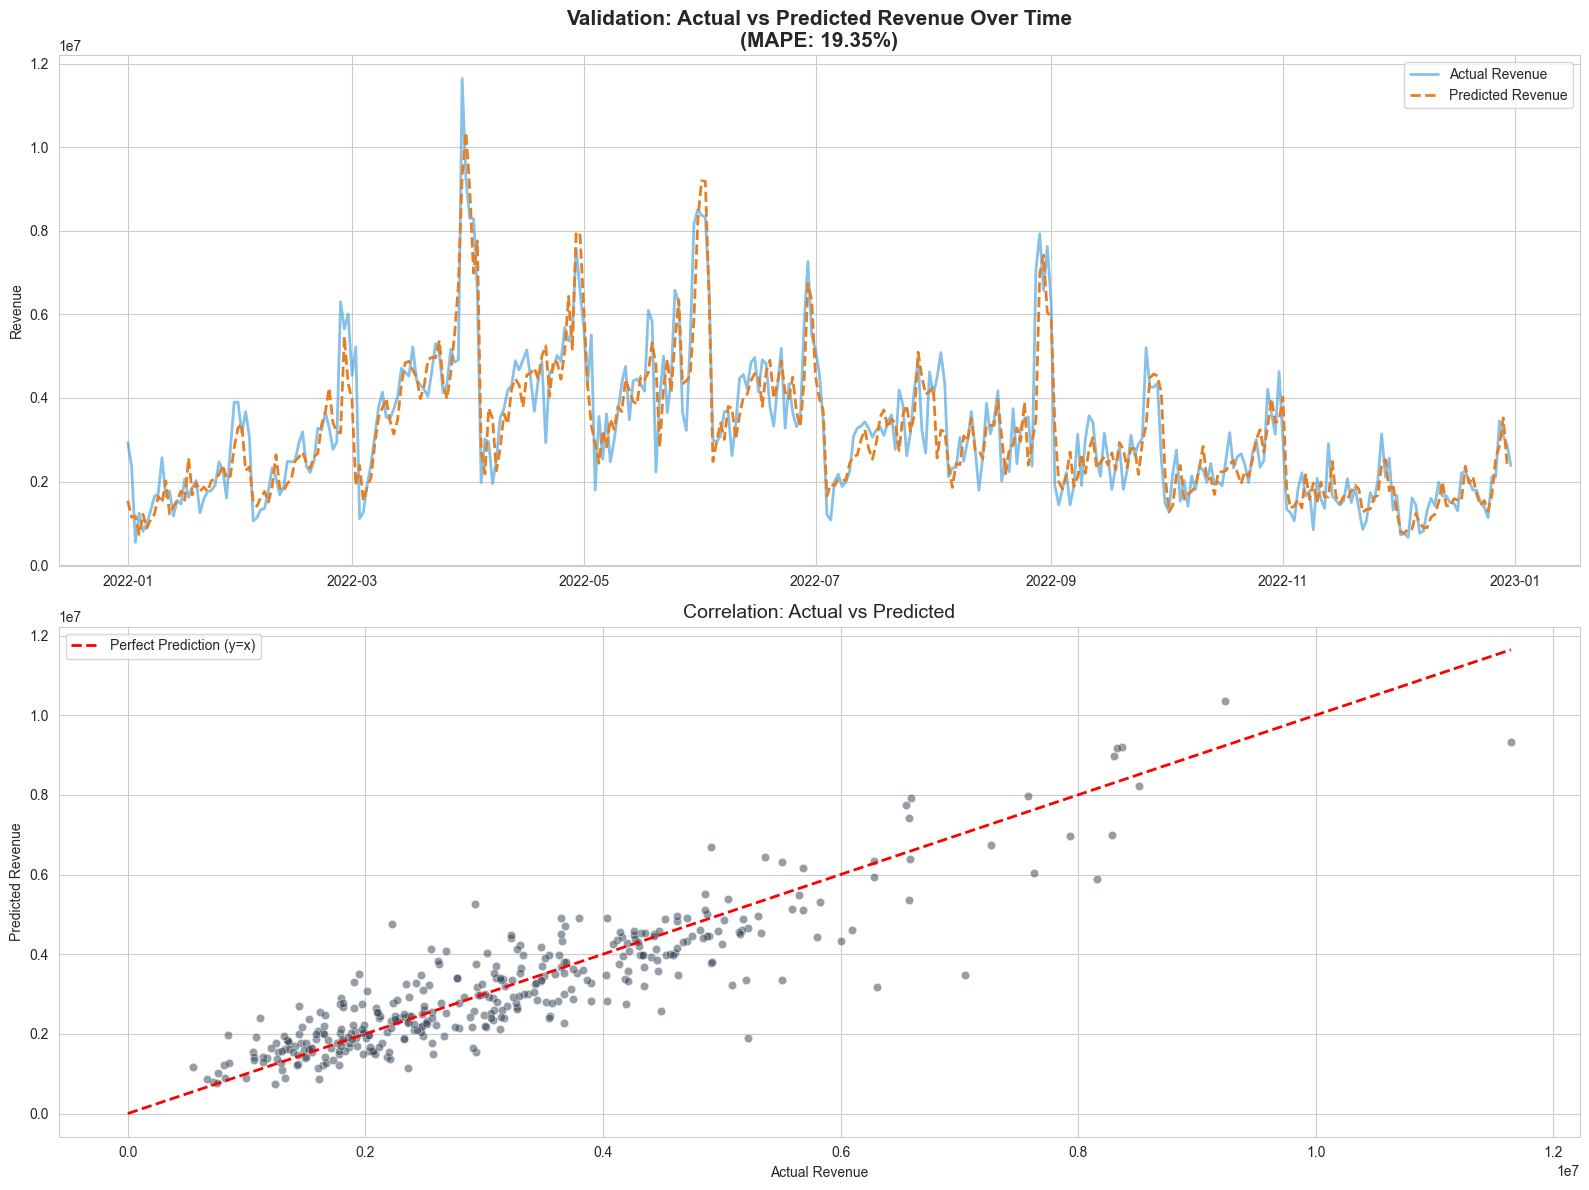

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo DataFrame phụ để vẽ cho dễ
df_val_plot = val_df[['Date']].copy()
df_val_plot['Actual'] = val_true
df_val_plot['Predicted'] = val_pred

# Thiết lập layout 2 biểu đồ
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
sns.set_style("whitegrid")

# --- BIỂU ĐỒ 1: SO SÁNH THEO THỜI GIAN ---
ax1.plot(df_val_plot['Date'], df_val_plot['Actual'], label='Actual Revenue', color='#3498db', alpha=0.6, linewidth=2)
ax1.plot(df_val_plot['Date'], df_val_plot['Predicted'], label='Predicted Revenue', color='#e67e22', linestyle='--', linewidth=2)
ax1.set_title(f'Validation: Actual vs Predicted Revenue Over Time\n(MAPE: {mape:.2f}%)', fontsize=15, fontweight='bold')
ax1.set_ylabel('Revenue')
ax1.legend()

# --- BIỂU ĐỒ 2: SCATTER PLOT (ACTUAL VS PREDICTED) ---
sns.scatterplot(x='Actual', y='Predicted', data=df_val_plot, ax=ax2, alpha=0.5, color='#2c3e50')
# Vẽ đường 45 độ (đường lý tưởng - nếu dự báo khớp 100%)
max_val = max(df_val_plot['Actual'].max(), df_val_plot['Predicted'].max())
ax2.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction (y=x)')

ax2.set_title('Correlation: Actual vs Predicted', fontsize=14)
ax2.set_xlabel('Actual Revenue')
ax2.set_ylabel('Predicted Revenue')
ax2.legend()

plt.tight_layout()
plt.show()

* Dù chỉ MAPE khá cao nhưng nhìn chung model cũng dự đoán khá tốt

---

## 7. Recursive Forecasting — Dự báo 2023–2024

### Tại sao cần Recursive Forecasting?

Lag features (`rev_lag_1`, `rev_lag_7`, `rev_lag_30`) cần giá trị Revenue của các ngày trước đó.
Trong giai đoạn test (2023–2024), ta **không có ground truth** → phải dùng giá trị dự báo để làm lag input cho ngày tiếp theo.

```
Ngày 1 (2023-01-01):
  → lag_1 = Revenue(2022-12-31) [từ train, có ground truth]
  → predict Revenue(2023-01-01) = P1

Ngày 2 (2023-01-02):
  → lag_1 = P1  [dùng giá trị vừa predict]
  → predict Revenue(2023-01-02) = P2

Ngày 8 (2023-01-08):
  → lag_1 = P7
  → lag_7 = P1  [predict của 7 ngày trước]
  → predict Revenue(2023-01-08) = P8
```

### Trade-off:
- **Ưu điểm**: Đơn giản, không cần biết tương lai
- **Nhược điểm**: Lỗi dự báo tích lũy theo thời gian (error accumulation) — lag_30 sau 1 tháng đã chứa 30 lần sai số

> **Cải tiến tiềm năng**: Thay lag features bằng calendar-only features (Fourier, promo schedule) để tránh error accumulation hoàn toàn.

In [7]:
# Tạo bản copy để cập nhật lag trong quá trình recursive
full_data  = df_final.copy()
test_dates = sorted(full_data[test_mask]['Date'].unique())

print(f"Bắt đầu dự báo đệ quy: {len(test_dates)} ngày ({test_dates[0].date()} → {test_dates[-1].date()})")
print("...")

for i, current_date in enumerate(test_dates):
    idx = full_data[full_data['Date'] == current_date].index[0]
    
    # Lấy feature vector của ngày hiện tại
    current_features = full_data.loc[[idx], FEATURES]
    
    # Dự báo log Revenue và log COGS
    pred_rev  = model_rev.predict(current_features)[0]
    pred_cogs = model_cogs.predict(current_features)[0]
    
    # Ghi kết quả vào dataframe (để tính lag cho các ngày sau)
    full_data.loc[idx, 'log_rev']  = pred_rev
    full_data.loc[idx, 'log_cogs'] = pred_cogs
    
    # Cập nhật lag features cho các ngày tương lai
    # Ví dụ: ngày 2023-01-01 sẽ là rev_lag_1 của 2023-01-02
    #                                   rev_lag_7 của 2023-01-08, v.v.
    for lag in [1, 2, 7, 14, 30]:
        future_date = current_date + pd.Timedelta(days=lag)
        future_idx  = full_data[full_data['Date'] == future_date].index
        if not future_idx.empty:
            full_data.loc[future_idx, f'rev_lag_{lag}']  = pred_rev
            full_data.loc[future_idx, f'cogs_lag_{lag}'] = pred_cogs
    
    # Progress log
    if (i + 1) % 100 == 0:
        print(f"  Đã dự báo {i+1}/{len(test_dates)} ngày...")

print("\n✅ Hoàn thành dự báo đệ quy!")

Bắt đầu dự báo đệ quy: 548 ngày (2023-01-01 → 2024-07-01)
...
  Đã dự báo 100/548 ngày...
  Đã dự báo 200/548 ngày...
  Đã dự báo 300/548 ngày...
  Đã dự báo 400/548 ngày...
  Đã dự báo 500/548 ngày...

✅ Hoàn thành dự báo đệ quy!


---

## 8. Export Submission

Chuyển ngược từ log-space về giá trị gốc bằng `expm1` (nghịch đảo của `log1p`):
- `expm1(x) = e^x - 1`
- Đây là nghịch đảo chính xác của `log1p(x) = log(1 + x)`

In [8]:
# Chuyển ngược: log → giá trị gốc
full_data['Revenue'] = np.expm1(full_data['log_rev'])
full_data['COGS']    = np.expm1(full_data['log_cogs'])

# Lấy kết quả test period
submission = full_data[test_mask][['Date', 'Revenue', 'COGS']].copy()

# Format
submission['Date']    = submission['Date'].dt.strftime('%Y-%m-%d')
submission['Revenue'] = submission['Revenue'].clip(lower=0).round(2)  # Clip âm về 0
submission['COGS']    = submission['COGS'].clip(lower=0).round(2)

# Lưu file
output_path = 'submission_recursive_final.csv'
submission.to_csv(output_path, index=False)

print("===== Submission Summary =====")
print(f"Rows     : {len(submission)}")
print(f"Saved to : {output_path}")
print(f"Revenue  : {submission['Revenue'].mean():>12,.0f} (mean) | {submission['Revenue'].min():>12,.0f} (min) | {submission['Revenue'].max():>12,.0f} (max)")
print(f"COGS     : {submission['COGS'].mean():>12,.0f} (mean) | {submission['COGS'].min():>12,.0f} (min) | {submission['COGS'].max():>12,.0f} (max)")
print("")
print(submission.head(10).to_string(index=False))

===== Submission Summary =====
Rows     : 548
Saved to : submission_recursive_final.csv
Revenue  :    4,227,522 (mean) |      717,880 (min) |   12,599,945 (max)
COGS     :    3,610,569 (mean) |      589,245 (min) |   10,868,792 (max)

      Date    Revenue       COGS
2023-01-01 1198679.70  942041.16
2023-01-02  787770.97  633200.17
2023-01-03  717879.99  589245.46
2023-01-04  797762.21  637700.05
2023-01-05  846993.22  705335.32
2023-01-06  930057.66  823445.53
2023-01-07 1017402.90  871548.66
2023-01-08 1220755.40 1016133.38
2023-01-09 1362571.38 1160531.68
2023-01-10 1228404.44 1056400.38


### 9. Biểu đồ hiển thị doanh thu từ 2012 - 2022 và dự báo ở 2 năm tiếp theo


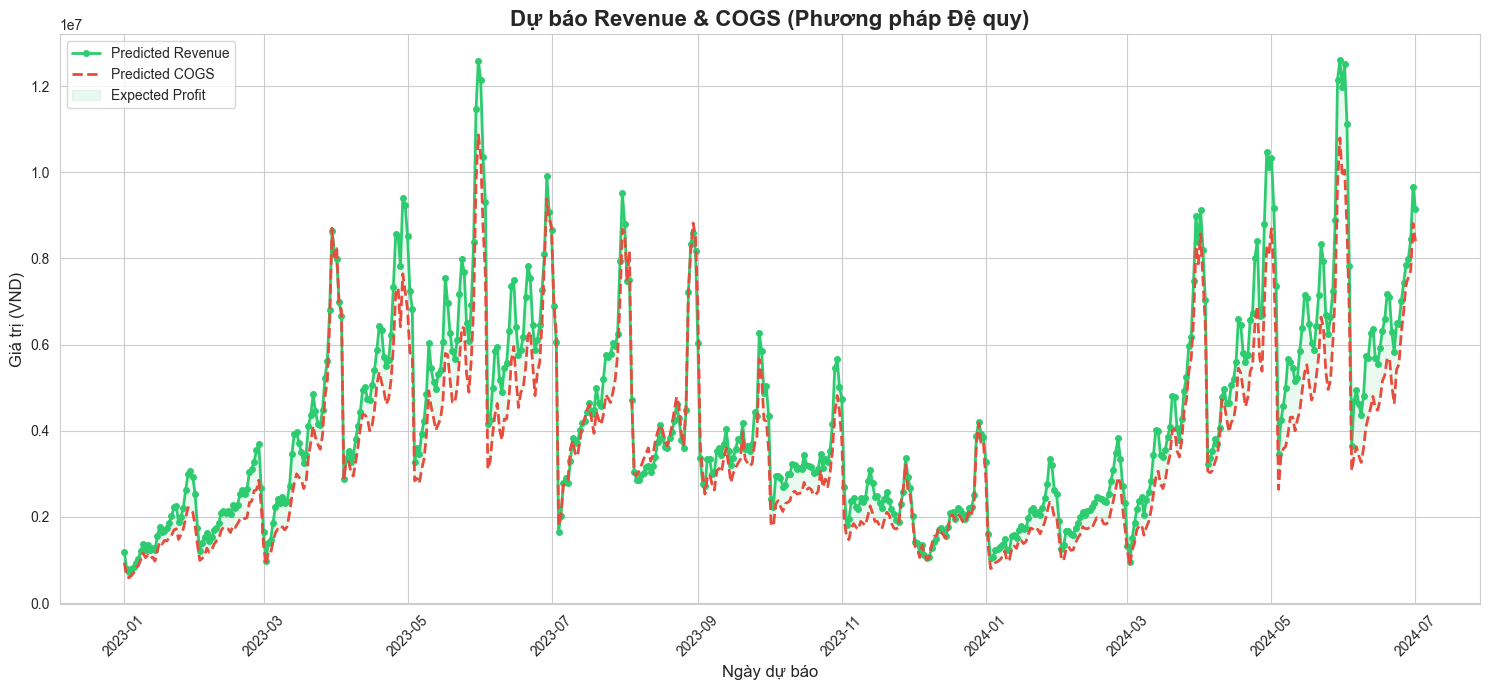

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Chuyển cột Date sang định dạng datetime để vẽ chart cho đúng thứ tự
submission_plot = submission.copy()
submission_plot['Date'] = pd.to_datetime(submission_plot['Date'])

# Khởi tạo khung hình
plt.figure(figsize=(15, 7))
sns.set_style("whitegrid")

# Vẽ đường Revenue
plt.plot(submission_plot['Date'], submission_plot['Revenue'], 
         label='Predicted Revenue', color='#2ecc71', linewidth=2, marker='o', markersize=4)

# Vẽ đường COGS
plt.plot(submission_plot['Date'], submission_plot['COGS'], 
         label='Predicted COGS', color='#e74c3c', linewidth=2, linestyle='--')

# Thêm vùng tô bóng giữa Revenue và COGS (tượng trưng cho Profit)
plt.fill_between(submission_plot['Date'], submission_plot['Revenue'], submission_plot['COGS'], 
                 where=(submission_plot['Revenue'] >= submission_plot['COGS']),
                 color='#2ecc71', alpha=0.1, label='Expected Profit')

# Cấu hình trục và tiêu đề
plt.title('Dự báo Revenue & COGS', fontsize=16, fontweight='bold')
plt.xlabel('Ngày dự báo', fontsize=12)
plt.ylabel('Giá trị (VND)', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Hiển thị
plt.show()